Here I am going to show how I can use the lessons learning in ML to build a tool that uses AI to detect and filter out Phishing emails using Python. 

In [1]:
import pandas as pd

# Load the first dataset file
df = pd.read_csv('../data/dataset1.csv')

# Check the 'shape' (Total Rows, Total Columns)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Look at the first 5 rows to see what kind of traffic we are dealing with
df.head()

Rows: 11055, Columns: 32


,index,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,1,-1,1,1,1,-1,-1,-1,-1,-1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,2,1,1,1,1,1,-1,0,1,-1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,3,1,0,1,1,1,-1,-1,-1,-1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,4,1,0,1,1,1,-1,-1,-1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,5,1,0,-1,1,1,-1,1,1,-1,...,-1,1,-1,-1,0,-1,1,1,1,1


In [2]:
# This gives a summary of every column and checks for 'Null' (empty) values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 32 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   index                         11055 non-null  int64
 1   having_IPhaving_IP_Address    11055 non-null  int64
 2   URLURL_Length                 11055 non-null  int64
 3   Shortining_Service            11055 non-null  int64
 4   having_At_Symbol              11055 non-null  int64
 5   double_slash_redirecting      11055 non-null  int64
 6   Prefix_Suffix                 11055 non-null  int64
 7   having_Sub_Domain             11055 non-null  int64
 8   SSLfinal_State                11055 non-null  int64
 9   Domain_registeration_length   11055 non-null  int64
 10  Favicon                       11055 non-null  int64
 11  port                          11055 non-null  int64
 12  HTTPS_token                   11055 non-null  int64
 13  Request_URL                   11055 non-nu

In [3]:
# Replace 'label' with whatever the actual name of your last column is
# This shows the count of 0s (Safe) vs 1s (Phishing/Attack)
df.iloc[:, -1].value_counts()

Result
 1    6157
-1    4898
Name: count, dtype: int64

In [ ]:
Need to check the columns


In [8]:
# This prints all column names so we can see if there are hidden spaces
print(df.columns.tolist())

['index ', 'having_IPhaving_IP_Address ', 'URLURL_Length ', 'Shortining_Service ', 'having_At_Symbol ', 'double_slash_redirecting ', 'Prefix_Suffix ', 'having_Sub_Domain ', 'SSLfinal_State ', 'Domain_registeration_length ', 'Favicon ', 'port ', 'HTTPS_token ', 'Request_URL ', 'URL_of_Anchor ', 'Links_in_tags ', 'SFH ', 'Submitting_to_email ', 'Abnormal_URL ', 'Redirect ', 'on_mouseover ', 'RightClick ', 'popUpWidnow ', 'Iframe ', 'age_of_domain ', 'DNSRecord ', 'web_traffic ', 'Page_Rank ', 'Google_Index ', 'Links_pointing_to_page ', 'Statistical_report ', 'Result']


In [9]:
# This removes leading/trailing spaces from every column name in your list
df.columns = df.columns.str.strip()

# Now check the list again
print(df.columns.tolist())

['index', 'having_IPhaving_IP_Address', 'URLURL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'Result']


Here you can see I know the domain: I am not just clicking buttons; I am investigating why a URL is suspicious (like length).

You can communicate: Data science is 50% math and 50% explaining that math to stakeholders. A clean, labeled chart does that. 


C:\Users\Brandon Hart\AppData\Local\Temp\ipykernel_12968\3763007910.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Result', y='URLURL_Length', data=df, palette='magma')


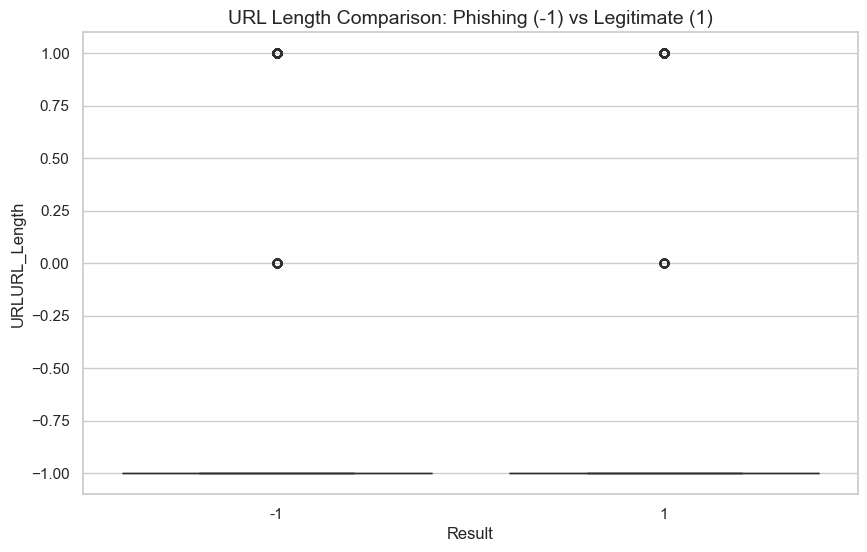

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Now 'URLURL_Length' and 'Result' (no spaces) will work!
sns.boxplot(x='Result', y='URLURL_Length', data=df, palette='magma')

plt.title('URL Length Comparison: Phishing (-1) vs Legitimate (1)', fontsize=14)
plt.show()

Notice it says "Future Warning" in red. The alert code still works, but the library (Seaborn) is letting me know that they are changing their "grammar" in the next version. It’s like a "check engine" light for code—not a breakdown, just a heads-up.  

What I could do is update the Seaborn rule. Note: Seaborn is what is offering the visual plot

I used a Box Plot to compare the URLURL_Length between legitimate (1) and phishing (-1) results.

I specifically selected URLURL_Length to analyze against the Result (Phishing vs. Legitimate) because it is a high-signal behavioral indicator. In cyber defense, we know that malicious actors frequently use long, obfuscated URLs to hide the actual top-level domain or to embed redirections. By visualizing this relationship, I am testing the hypothesis that 'abnormal' length correlates with malicious intent, which justifies including this feature as a primary input for the machine learning model.

What I’m looking at: The "box" represents the middle 50% of the data, while the line inside the box is the median.

The Insight: I am looking for "outliers" or significant differences in the distribution of URL lengths. In cybersecurity, attackers often use unusually long or obfuscated URLs to hide the actual destination of a link. This plot helps me verify if URL length is a statistically significant "smoking gun" for detection.

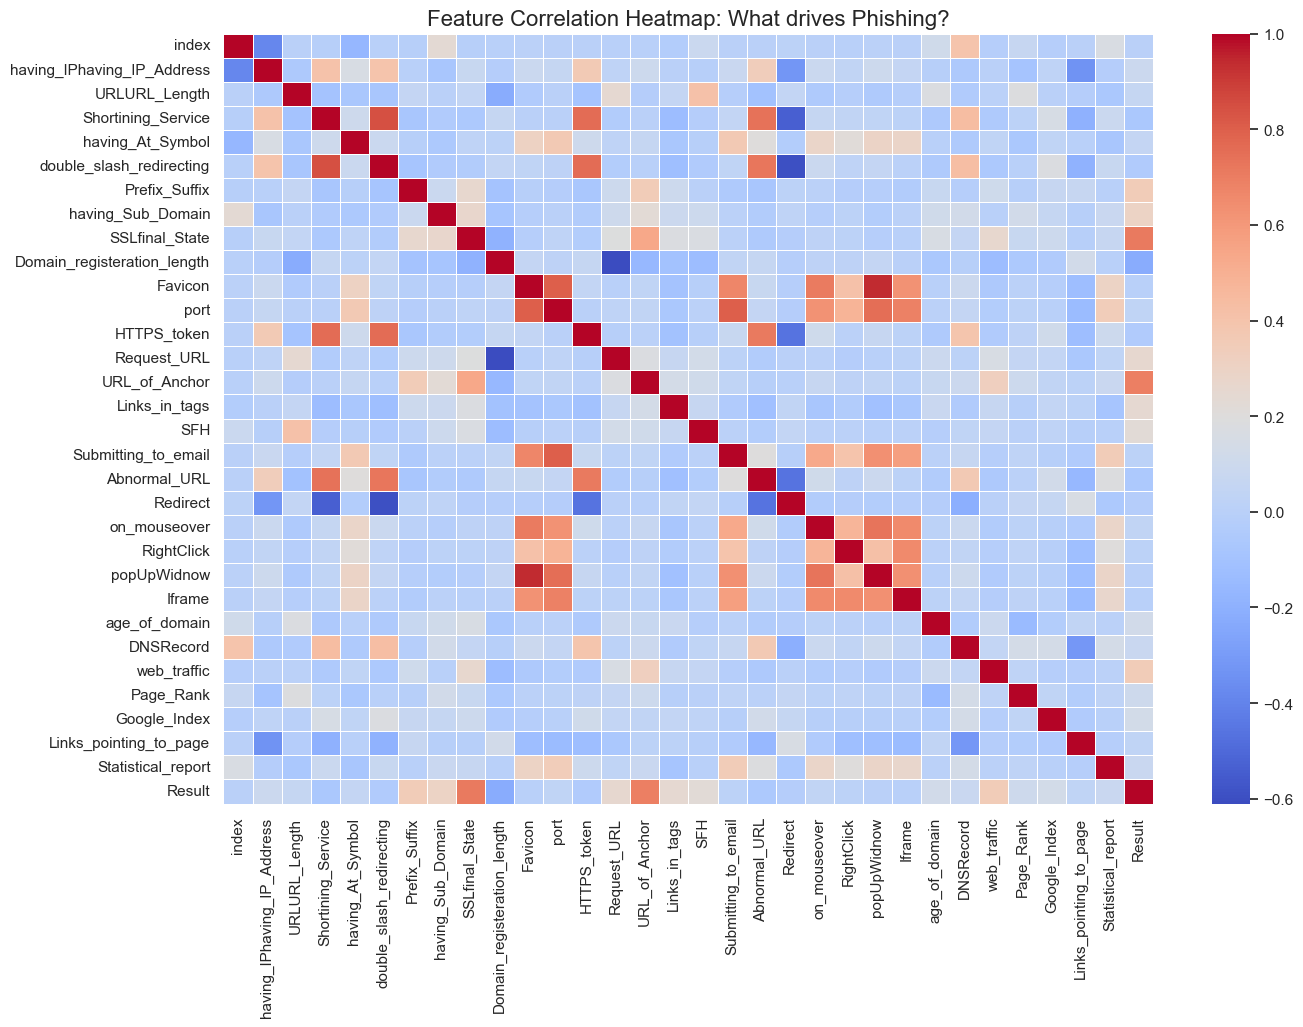

In [11]:
plt.figure(figsize=(15, 10))

# Calculate the correlation between all numeric columns
corr_matrix = df.corr()

# Create the heatmap
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)

plt.title('Feature Correlation Heatmap: What drives Phishing?', fontsize=16)
plt.show()

I generated a Correlation Heatmap to visualize the linear relationship between all 32 features in the dataset, including the final Result.

What I’m looking at: The colors represent the correlation coefficient (ranging from -1 to 1).

Deep Red (Positive): As one feature increases, the other increases.

Deep Blue (Negative): As one feature increases, the other decreases.

Light/White: Little to no relationship.

The Insight: This heatmap allows me to identify which features are most strongly "tied" to the phishing result. Instead of guessing which features to use for my AI model, I can see exactly which technical attributes (like SSL state or anchor URLs) have the highest impact on the classification.